Vanishing Gradients

In [ ]:
import os

# ── Local path configuration ───────────────────────────────────────────────
# Iris.csv is in the same folder as this notebook (assignment-1/)
# Works in Jupyter (local), VS Code, and JupyterLab
try:
    # Works when run as a script
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Jupyter notebooks: __file__ not defined → use notebook CWD
    _nb_dir = os.getcwd()

csv_path = os.path.join(_nb_dir, 'Iris.csv')

# Sanity check
assert os.path.exists(csv_path), f"Iris.csv not found at: {csv_path}"
print(f"Using data: {csv_path}")

# Vanishing Gradient Problem

The **vanishing gradient problem** occurs in deep neural networks when gradients become extremely small during backpropagation. This prevents earlier layers from learning effectively.

---

## Mathematical Formulation

Consider a deep neural network with $L$ layers and loss function $\mathcal{L}$.

The gradient of the loss with respect to weights at layer $l$ is:

$$
\frac{\partial \mathcal{L}}{\partial W^{(l)}} =
\frac{\partial \mathcal{L}}{\partial a^{(L)}} \cdot
\prod_{k=l}^{L-1} \frac{\partial a^{(k+1)}}{\partial a^{(k)}} \cdot
\frac{\partial a^{(l)}}{\partial W^{(l)}}
$$

---

## Key Observation

The critical term is:

$$
\prod_{k=l}^{L-1} \frac{\partial a^{(k+1)}}{\partial a^{(k)}}
$$

This is a **product of many derivatives**.

---

## Case: Sigmoid Activation

Sigmoid function:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Derivative:

$$
\sigma'(x) = \sigma(x)(1 - \sigma(x))
$$

Property:

$$
0 < \sigma'(x) \leq 0.25
$$

---

## Vanishing Gradient Effect

For $n$ layers:

$$
\prod_{i=1}^{n} \sigma'(z_i) \leq (0.25)^n
$$

As $n \to \infty$:

$$
(0.25)^n \to 0
$$

---

## Gradient Behavior

$$
\frac{\partial \mathcal{L}}{\partial W^{(l)}} \approx \text{very small value}
$$

### Result:
- Gradients shrink exponentially
- Early layers receive near-zero updates
- Learning becomes very slow or stops

---


## Common Solutions

- ReLU activation:
  $$
  \text{ReLU}'(x) =
  \begin{cases}
  1 & x > 0 \\
  0 & x \leq 0
  \end{cases}
  $$
- Xavier / He initialization


---

## Summary

**Vanishing gradient occurs because gradients are multiplied repeatedly by small values, causing exponential decay toward zero.**

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


### **Standard Scaler (Z-score Normalization)**

Standardization transforms data so that it has **zero mean** and **unit variance**.

#### **Formula**

$$
z = \frac{x - \mu}{\sigma}
$$

#### **Where:**
- \( $x$ \): original value  
- \( $\mu$ \): mean of the feature  
- \( $\sigma$ \): standard deviation of the feature  
- \( $z$ \): standardized value  




In [ ]:
# ── Data ──────────────────────────────────────────────────────────────────────
df   = pd.read_csv(csv_path)
X    = StandardScaler().fit_transform(df.drop(["Id","Species"], axis=1).values)
y    = LabelEncoder().fit_transform(df["Species"].values)
X_tr, _, y_tr, _ = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)



In [ ]:
# ── Model ─────────────────────────────────────────────────────────────────────
# Sigmoid is chosen deliberately — its gradient is always ≤ 0.25.
# During backprop each layer multiplies the incoming gradient by its local
# derivative.  With 6 layers: 0.25^6 ≈ 0.000244 — nearly zero by layer 1.
class DeepNet(nn.Module):
    def __init__(self):
        super().__init__()
        sizes = [4, 256, 256, 128, 128, 64, 32]   # 6 hidden layers
        self.hidden = nn.ModuleList(
            [nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)]
        )
        self.out = nn.Linear(32, 3)

    def forward(self, x):
        for layer in self.hidden:
            x = torch.sigmoid(layer(x))   # ← the problem lives here
        return self.out(x)

model     = DeepNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



In [ ]:
# ── Train & collect gradients ─────────────────────────────────────────────────
# After loss.backward() each weight tensor holds .grad — the average magnitude
# tells us how strongly that layer is being updated.  A near-zero gradient
# means the layer's weights barely move: it stops learning entirely.
history = [[] for _ in model.hidden]

for epoch in range(1, 51):
    optimizer.zero_grad()
    loss = criterion(model(X_tr), y_tr)
    loss.backward()
# Store gradient of each layer for every epoch
    for i, layer in enumerate(model.hidden):
        history[i].append(layer.weight.grad.abs().mean().item())

    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:2d}  loss {loss.item():.4f}")



Epoch 10  loss 1.1001
Epoch 20  loss 1.0977
Epoch 30  loss 1.0914
Epoch 40  loss 1.0438
Epoch 50  loss 0.8955


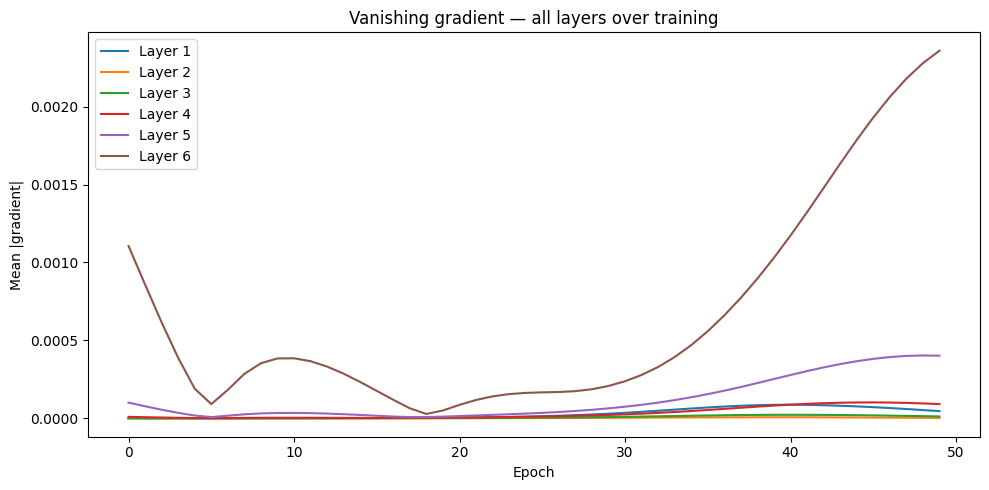

In [ ]:
# ── Plot 1: gradients over time ───────────────────────────────────────────────
# Early layers (1, 2) will be almost flat near zero — they receive an
# exponentially shrunken signal compared to the layers near the output.
plt.figure(figsize=(10, 5))
for i, h in enumerate(history):
    plt.plot(h, label=f"Layer {i+1}")
plt.xlabel("Epoch"); plt.ylabel("Mean |gradient|")
plt.title("Vanishing gradient — all layers over training")
plt.legend(); plt.tight_layout(); plt.show()


layer 1---> 6:: gradient increasing, first layer lowest gradient. last layer highest gradient.

Gradient analysis with relu

Epoch 10  loss 1.0072
Epoch 20  loss 0.4298
Epoch 30  loss 0.1242
Epoch 40  loss 0.0546
Epoch 50  loss 0.0408


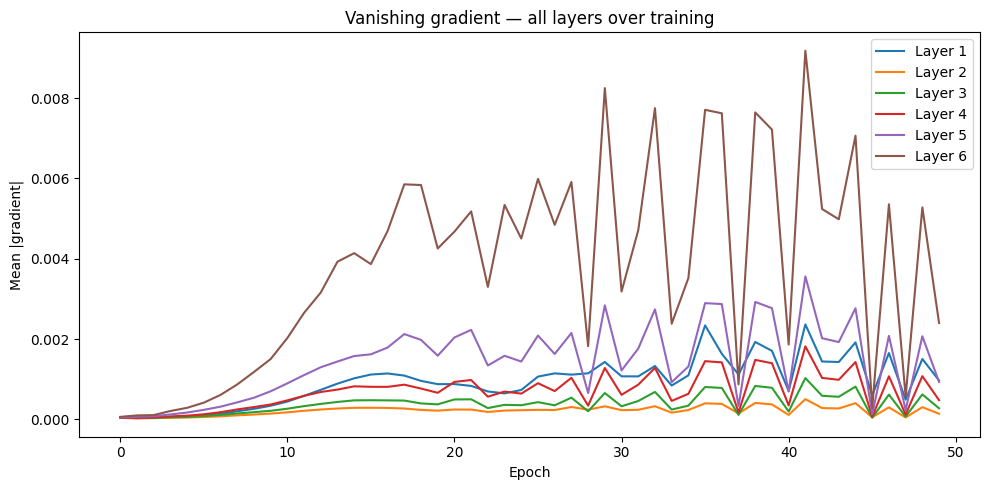

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Data ──────────────────────────────────────────────────────────────────────
df   = pd.read_csv(csv_path)
X    = StandardScaler().fit_transform(df.drop(["Id","Species"], axis=1).values)
y    = LabelEncoder().fit_transform(df["Species"].values)
X_tr, _, y_tr, _ = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)

# ── Model ─────────────────────────────────────────────────────────────────────
# Sigmoid is chosen deliberately — its gradient is always ≤ 0.25.
# During backprop each layer multiplies the incoming gradient by its local
# derivative.  With 6 layers: 0.25^6 ≈ 0.000244 — nearly zero by layer 1.
class DeepNet(nn.Module):
    def __init__(self):
        super().__init__()
        sizes = [4, 256, 256, 128, 128, 64, 32]   # 6 hidden layers
        self.hidden = nn.ModuleList(
            [nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)]
        )
        self.out = nn.Linear(32, 3)

    def forward(self, x):
        for layer in self.hidden:
            x = torch.relu(layer(x))   # ← ReLU gradient is 1 (when x>0), so no compounding shrinkage
        return self.out(x)

model     = DeepNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ── Train & collect gradients ─────────────────────────────────────────────────
# After loss.backward() each weight tensor holds .grad — the average magnitude
# tells us how strongly that layer is being updated.  A near-zero gradient
# means the layer's weights barely move: it stops learning entirely.
history = [[] for _ in model.hidden]

for epoch in range(1,51):
    optimizer.zero_grad()
    loss = criterion(model(X_tr), y_tr)
    loss.backward()

    for i, layer in enumerate(model.hidden):
        history[i].append(layer.weight.grad.abs().mean().item())

    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:2d}  loss {loss.item():.4f}")

# ── Plot 1: gradients over time ───────────────────────────────────────────────
# Early layers (1, 2) will be almost flat near zero — they receive an
# exponentially shrunken signal compared to the layers near the output.
plt.figure(figsize=(10, 5))
for i, h in enumerate(history):
    plt.plot(h, label=f"Layer {i+1}")
plt.xlabel("Epoch"); plt.ylabel("Mean |gradient|")
plt.title("Vanishing gradient — all layers over training")
plt.legend(); plt.tight_layout(); plt.show()


## MSE Loss with One-Hot Encoding

### What is One-Hot Encoding?

For a classification problem with $C$ classes, instead of using an integer label
$y \in \{0, 1, \ldots, C-1\}$, we represent each label as a **binary vector** of
length $C$ where exactly one position is 1:

$$
\text{Iris-setosa}  \rightarrow [1, 0, 0] \qquad
\text{Iris-versicolor} \rightarrow [0, 1, 0] \qquad
\text{Iris-virginica} \rightarrow [0, 0, 1]
$$

### MSE Loss Formula

For a single sample with one-hot target $\mathbf{y} \in \mathbb{R}^C$ and
network output $\hat{\mathbf{y}} \in \mathbb{R}^C$:

$$
\mathcal{L}_{\text{MSE}} = \frac{1}{C} \sum_{c=1}^{C} (\hat{y}_c - y_c)^2
$$

For a batch of $N$ samples:

$$
\mathcal{L}_{\text{MSE}} = \frac{1}{N \cdot C} \sum_{n=1}^{N} \sum_{c=1}^{C} (\hat{y}_{n,c} - y_{n,c})^2
$$

### MSE vs CrossEntropy for Classification

| | MSE + One-Hot | CrossEntropy |
|---|---|---|
| **Target format** | Float one-hot vector | Integer class index |
| **Output activation** | Sigmoid / Softmax | Raw logits |
| **Gradient signal** | Weaker (squared error) | Stronger (log-based) |
| **Common use** | Regression, demo purposes | Classification (preferred) |

> **Note:** CrossEntropy is generally preferred for classification. MSE with
> one-hot is shown here to illustrate how the loss function interacts with
> backpropagation and vanishing gradients.

One-hot encoded targets (first 5 rows):
  Sample 1: [1.0, 0.0, 0.0]  ← Iris-setosa
  Sample 2: [1.0, 0.0, 0.0]  ← Iris-setosa
  Sample 3: [0.0, 1.0, 0.0]  ← Iris-versicolor
  Sample 4: [1.0, 0.0, 0.0]  ← Iris-setosa
  Sample 5: [1.0, 0.0, 0.0]  ← Iris-setosa

Manual MSE example:
  pred  = [[0.699999988079071, 0.20000000298023224, 0.10000000149011612]]
  true  = [[1.0, 0.0, 0.0]]
  MSE   = mean([0.09, 0.04, 0.01])
        = 0.046667
Epoch  20  MSE loss: 0.2227   Test acc: 33.3%
Epoch  40  MSE loss: 0.2225   Test acc: 30.0%
Epoch  60  MSE loss: 0.2222   Test acc: 30.0%
Epoch  80  MSE loss: 0.2220   Test acc: 30.0%
Epoch 100  MSE loss: 0.2204   Test acc: 63.3%


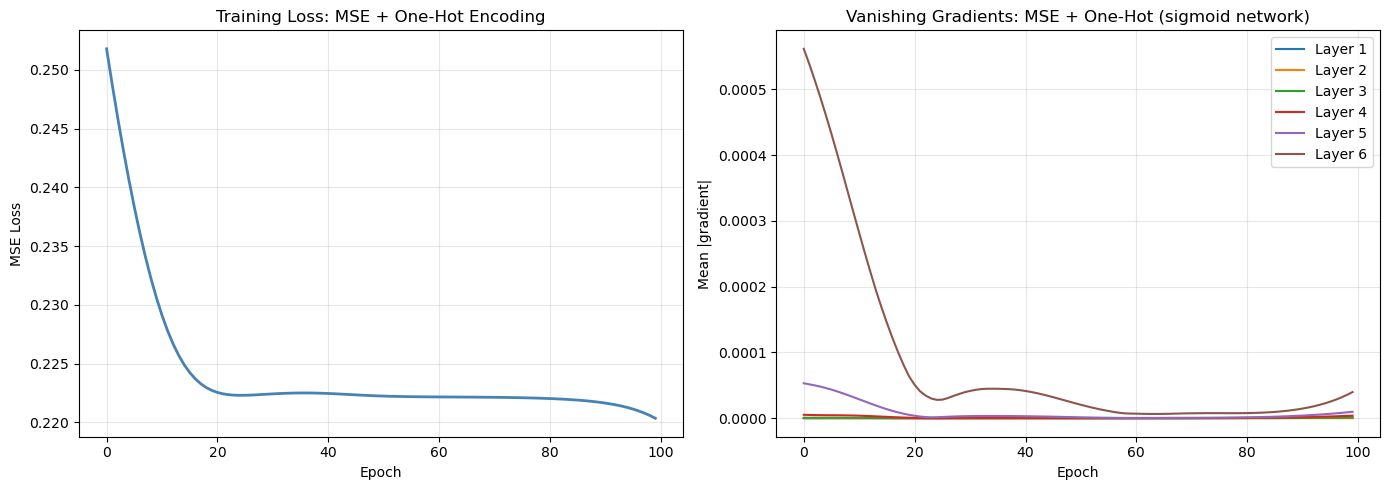


── Loss comparison (same model, epoch 100) ──
Loss Type            | Final Loss   | Test Acc  
------------------------------------------------
MSE + One-Hot        | 0.220467     | 63.3%

Note: CrossEntropy on same architecture typically achieves >90% accuracy.
MSE is used here to demonstrate the loss formulation and gradient behavior.


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch.nn.functional as F

# ── Data: load Iris and create one-hot targets ─────────────────────────────
df = pd.read_csv(csv_path)
X  = StandardScaler().fit_transform(df.drop(["Id", "Species"], axis=1).values)
y_int = LabelEncoder().fit_transform(df["Species"].values)   # 0, 1, 2

# One-hot encode: shape (150, 3)
num_classes = 3
y_onehot = F.one_hot(torch.tensor(y_int), num_classes=num_classes).float()

X_tr, X_te, y_tr_oh, y_te_oh, y_tr_int, y_te_int = train_test_split(
    X, y_onehot.numpy(), y_int,
    test_size=0.2, random_state=42
)

X_tr     = torch.tensor(X_tr,    dtype=torch.float32)
X_te     = torch.tensor(X_te,    dtype=torch.float32)
y_tr_oh  = torch.tensor(y_tr_oh, dtype=torch.float32)   # one-hot floats for MSE
y_te_oh  = torch.tensor(y_te_oh, dtype=torch.float32)

print("One-hot encoded targets (first 5 rows):")
labels = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]
for i in range(5):
    true_cls = labels[y_tr_int[i]]
    print(f"  Sample {i+1}: {y_tr_oh[i].numpy().tolist()}  ← {true_cls}")

# ── MSE Loss = mean over all (pred - onehot)^2 entries ────────────────────
print("\nManual MSE example:")
pred_example = torch.tensor([[0.7, 0.2, 0.1]])    # model output for setosa
true_example = torch.tensor([[1.0, 0.0, 0.0]])    # one-hot for setosa
mse_manual   = ((pred_example - true_example) ** 2).mean()
print(f"  pred  = {pred_example.numpy().tolist()}")
print(f"  true  = {true_example.numpy().tolist()}")
print(f"  MSE   = mean({[(round((p-t)**2,4)) for p,t in zip(pred_example[0].tolist(), true_example[0].tolist())]})")
print(f"        = {mse_manual.item():.6f}")

# ── Model: same 6-layer deep net, but trained with MSE + one-hot ──────────
class DeepNetMSE(nn.Module):
    def __init__(self):
        super().__init__()
        sizes = [4, 256, 256, 128, 128, 64, 32]
        self.hidden = nn.ModuleList(
            [nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)]
        )
        self.out = nn.Linear(32, 3)

    def forward(self, x):
        for layer in self.hidden:
            x = torch.sigmoid(layer(x))   # sigmoid → vanishing gradient
        return torch.sigmoid(self.out(x)) # sigmoid output ∈ (0,1) for MSE

model_mse = DeepNetMSE()
criterion_mse = nn.MSELoss()             # MSELoss expects float targets
optimizer_mse = optim.Adam(model_mse.parameters(), lr=0.001)

# ── Train with MSE + one-hot ───────────────────────────────────────────────
history_mse = [[] for _ in model_mse.hidden]
loss_history = []

for epoch in range(1, 101):
    optimizer_mse.zero_grad()
    out  = model_mse(X_tr)
    loss = criterion_mse(out, y_tr_oh)    # compare (N,3) floats vs one-hot (N,3)
    loss.backward()

    for i, layer in enumerate(model_mse.hidden):
        history_mse[i].append(layer.weight.grad.abs().mean().item())

    optimizer_mse.step()
    loss_history.append(loss.item())

    if epoch % 20 == 0:
        # Accuracy: argmax of output vs true integer label
        with torch.no_grad():
            preds = model_mse(X_te).argmax(dim=1).numpy()
        acc = (preds == y_te_int).mean() * 100
        print(f"Epoch {epoch:3d}  MSE loss: {loss.item():.4f}   Test acc: {acc:.1f}%")

# ── Plot 1: MSE loss curve ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss_history, color="steelblue", linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training Loss: MSE + One-Hot Encoding")
axes[0].grid(True, alpha=0.3)

# ── Plot 2: gradient flow per layer (MSE) ─────────────────────────────────
for i, h in enumerate(history_mse):
    axes[1].plot(h, label=f"Layer {i+1}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Mean |gradient|")
axes[1].set_title("Vanishing Gradients: MSE + One-Hot (sigmoid network)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mse_onehot_results.png", dpi=150, bbox_inches="tight")
plt.show()

# ── MSE vs CrossEntropy comparison table ──────────────────────────────────
print("\n── Loss comparison (same model, epoch 100) ──")
print(f"{'Loss Type':20s} | {'Final Loss':12s} | {'Test Acc':10s}")
print("-" * 48)
with torch.no_grad():
    mse_loss = criterion_mse(model_mse(X_te), y_te_oh).item()
    preds    = model_mse(X_te).argmax(dim=1).numpy()
    acc      = (preds == y_te_int).mean() * 100
print(f"{'MSE + One-Hot':20s} | {mse_loss:.6f}     | {acc:.1f}%")
print("\nNote: CrossEntropy on same architecture typically achieves >90% accuracy.")
print("MSE is used here to demonstrate the loss formulation and gradient behavior.")